# *Predicting the continent of a flag*

In this ML project we will be predicting the continent of a flag based on a number of features that describe it. We have determined decision trees would be the most optimal modeling for this purpose. 

The dataset could be found at the University of California Irvine Machine Learning repository: https://archive.ics.uci.edu/dataset/40/flags
Please refer to this legend for more information how the variables translate to real world context:
   1. name:	Name of the country concerned
   2. landmass:	1=N.America, 2=S.America, 3=Europe, 4=Africa, 4=Asia, 6=Oceania
   3. zone:	Geographic quadrant, based on Greenwich and the Equator; 1=NE, 2=SE, 3=SW, 4=NW
   4. area:	in thousands of square km
   5. population:	in round millions
   6. language: 1=English, 2=Spanish, 3=French, 4=German, 5=Slavic, 6=Other Indo-European, 7=Chinese, 8=Arabic, 9=Japanese/Turkish/Finnish/Magyar, 10=Others
   7. religion: 0=Catholic, 1=Other Christian, 2=Muslim, 3=Buddhist, 4=Hindu, 5=Ethnic, 6=Marxist, 7=Others
   8. bars:     Number of vertical bars in the flag
   9. stripes:  Number of horizontal stripes in the flag
  10. colours:  Number of different colours in the flag
  11. red:      0 if red absent, 1 if red present in the flag
  12. green:    same for green
  13. blue:     same for blue
  14. gold:     same for gold (also yellow)
  15. white:    same for white
  16. black:    same for black
  17. orange:   same for orange (also brown)
  18. mainhue:  predominant colour in the flag (tie-breaks decided by taking the topmost hue, if that fails then the most central hue, and if that fails the leftmost hue)
  19. circles:  Number of circles in the flag
  20. crosses:  Number of (upright) crosses
  21. saltires: Number of diagonal crosses
  22. quarters: Number of quartered sections
  23. sunstars: Number of sun or star symbols
  24. crescent: 1 if a crescent moon symbol present, else 0
  25. triangle: 1 if any triangles present, 0 otherwise
  26. icon:     1 if an inanimate image present (e.g., a boat), otherwise 0
  27. animate:  1 if an animate image (e.g., an eagle, a tree, a human hand) present, 0 otherwise
  28. text:     1 if any letters or writing on the flag (e.g., a motto or slogan), 0 otherwise
  29. topleft:  colour in the top-left corner (moving right to decide tie-breaks)
  30. botright: Colour in the bottom-left corner (moving left to decide tie-breaks)

In [2]:
# import neccessary dataframes
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

In [3]:
# Load dataset into pandas dataframe
flags=pd.read_csv("data/flags.csv",header=None)
flags.columns=['Name', 'Landmass', 'Zone', 'Area', 'Population', 'Language',
       'Religion', 'Bars', 'Stripes', 'Colors', 'Red', 'Green', 'Blue', 'Gold',
       'White', 'Black', 'Orange', 'Mainhue', 'Circles', 'Crosses', 'Saltires',
       'Quarters', 'Sunstars', 'Crescent', 'Triangle', 'Icon', 'Animate',
       'Text', 'Topleft', 'Botright']
flags.head()

,Name,Landmass,Zone,Area,Population,Language,Religion,Bars,Stripes,Colors,...,Saltires,Quarters,Sunstars,Crescent,Triangle,Icon,Animate,Text,Topleft,Botright
0,Afghanistan,5,1,648,16,10,2,0,3,5,...,0,0,1,0,0,1,0,0,black,green
1,Albania,3,1,29,3,6,6,0,0,3,...,0,0,1,0,0,0,1,0,red,red
2,Algeria,4,1,2388,20,8,2,2,0,3,...,0,0,1,1,0,0,0,0,green,white
3,American-Samoa,6,3,0,0,1,1,0,0,5,...,0,0,0,0,1,1,1,0,blue,red
4,Andorra,3,1,0,0,6,0,3,0,3,...,0,0,0,0,0,0,0,0,blue,red


## Lets model the tree on select features that reflect the various components of the flag.

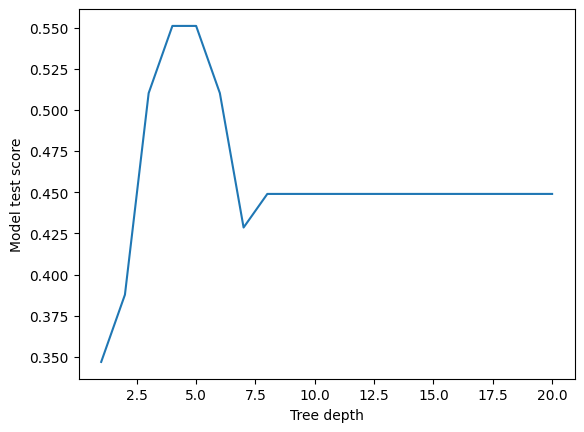

In [4]:
labels=flags["Landmass"]
data=flags[["Red", "Green", "Blue", "Gold",
 "White", "Black", "Orange",
 "Circles",
"Crosses","Saltires","Quarters","Sunstars",
"Crescent","Triangle"]]

train_data,test_data,train_labels,test_labels=train_test_split(data,labels,random_state=1)
scores=[]
for i in range(1,21):
  tree=DecisionTreeClassifier(random_state=1,max_depth=i)
  tree.fit(train_data,train_labels)
  scores.append(tree.score(test_data,test_labels))
plt.plot(range(1,21),scores)
plt.xlabel("Tree depth")
plt.ylabel("Model test score")
plt.show()

## We can see from the graph the depth of the tree has significant effects on the accuracy of the model reflected in the score. The maximum the score we were are able to achieve is 0.550, which is certainly better than a random guess, that would have  an accuracy of 1/6. Lets try now to improve the accuracy by including more features.

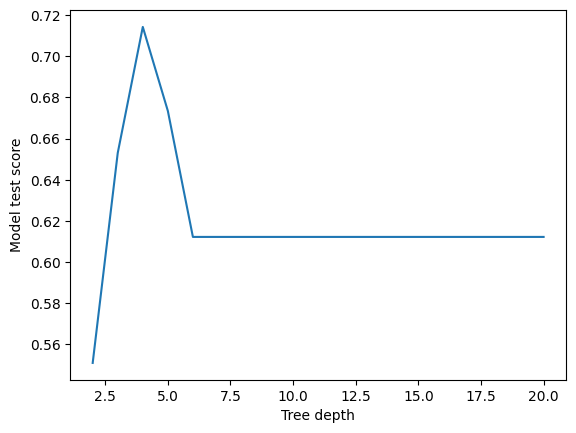

In [5]:
labels=flags["Landmass"]
data=flags[['Zone', 'Area', 'Population', 'Language',
       'Religion', 'Bars', 'Stripes', 'Colors', 'Red', 'Green', 'Blue', 'Gold',
       'White', 'Black', 'Orange', 'Circles', 'Crosses', 'Saltires',
       'Quarters', 'Sunstars', 'Crescent', 'Triangle', 'Icon', 'Animate',
       'Text']]
train_data,test_data,train_labels,test_labels=train_test_split(data,labels,random_state=1)
scores=[]
for i in range(2,21):
  tree=DecisionTreeClassifier(random_state=1,max_depth=i)
  tree.fit(train_data,train_labels)
  scores.append(tree.score(test_data,test_labels))
plt.plot(range(2,21),scores)
plt.xlabel("Tree depth")
plt.ylabel("Model test score")
plt.show()

## It can be observed that including more features has increased our model accuracy to a peak value of 0.725. Lets further explore if we can tune more parameters.

## Lets check if we can improve our score through cross-validation over a range of tree depths.

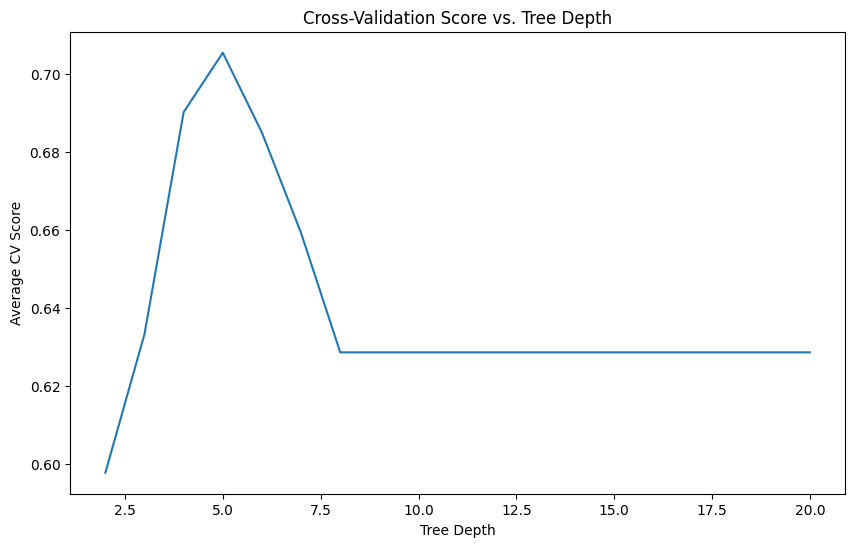

In [6]:
from sklearn.model_selection import cross_val_score
labels=flags["Landmass"]
data=flags[['Zone', 'Area', 'Population', 'Language',
       'Religion', 'Bars', 'Stripes', 'Colors', 'Red', 'Green', 'Blue', 'Gold',
       'White', 'Black', 'Orange', 'Circles', 'Crosses', 'Saltires',
       'Quarters', 'Sunstars', 'Crescent', 'Triangle', 'Icon', 'Animate',
       'Text']]
# Define tree depths to test
tree_depths = range(2, 21)
cv_scores = []

# Perform 5-fold cross-validation for each tree depth
for depth in tree_depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=1)
    scores = cross_val_score(tree,data,labels, cv=5)
    cv_scores.append(scores.mean())

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(tree_depths, cv_scores)
plt.xlabel('Tree Depth')
plt.ylabel('Average CV Score')
plt.title('Cross-Validation Score vs. Tree Depth')
plt.show()

## It can be observed that we have achieved similar outputs when using single split modeling vs cross-validation and that the optimal tree depth is 6 for this dataset. While the single split approach provides a quick estimate of model performance, cross-validation offers a more robust evaluation by averaging performance across multiple data splits. This reduces the risk of overfitting and that the score is not significantly affected by randomness in the dataset that could be amplified by the selection of tree depth.

 ## Lets now train the model on the optimal hyperparameters we have found.

In [28]:
train_data,test_data,train_labels,test_labels=train_test_split(data,labels,test_size=0.2,random_state=1)
tree=DecisionTreeClassifier(random_state=1,max_depth=6)
tree.fit(train_data,train_labels)
print(tree.score(train_data,train_labels))
print(tree.score(test_data,test_labels))

0.967741935483871
0.6923076923076923
